In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
import sklearn

df = pd.read_csv("D:\\ML\\Employee Attrition Prediction Dataset.csv")
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (74498, 24)


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [2]:
# Encode target (Stayed=0, Left=1)
df["Attrition_Enc"] = df["Attrition"].map({"Stayed": 0, "Left": 1})
y = df["Attrition_Enc"]

cols_to_drop = ["Employee ID"] 
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

In [3]:
X = df.drop(columns=["Attrition", "Attrition_Enc"])

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

# sklearn version 
sk_version = sklearn.__version__
if int(sk_version.split(".")[1]) >= 2:
    encoder = OneHotEncoder(drop="first", sparse_output=False)
else:
    encoder = OneHotEncoder(drop="first", sparse=False)

X_encoded = pd.DataFrame(
    encoder.fit_transform(X[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols)
)

X_all = pd.concat([X[numeric_cols].reset_index(drop=True),
                   X_encoded.reset_index(drop=True)], axis=1)

print("Final feature matrix shape:", X_all.shape)


Final feature matrix shape: (74498, 41)


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

print("Shape after scaling:", X_scaled.shape)


Shape after scaling: (74498, 41)


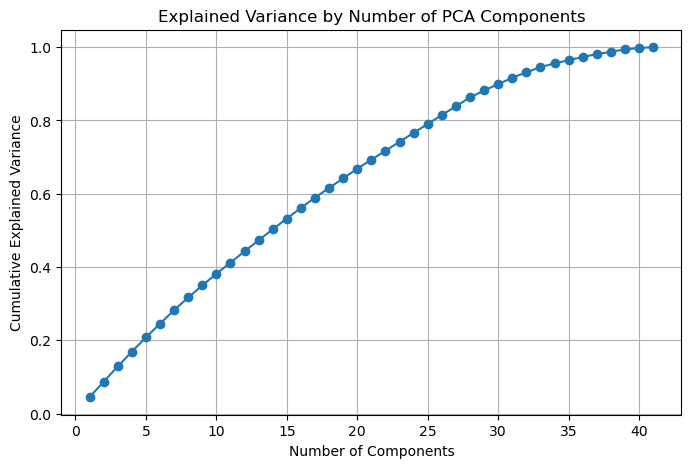

In [5]:
pca = PCA(n_components=None)
pca.fit(X_scaled)

# Cumulative variance explained
plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(), marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by Number of PCA Components")
plt.grid(True)
plt.show()


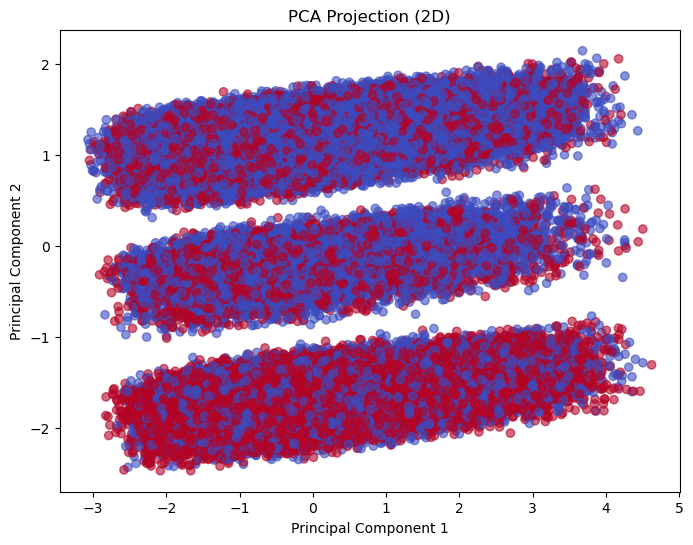

Explained variance ratio (2 PCs): [0.04452238 0.04242259]


In [6]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="coolwarm", alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection (2D)")
plt.show()

print("Explained variance ratio (2 PCs):", pca_2d.explained_variance_ratio_)


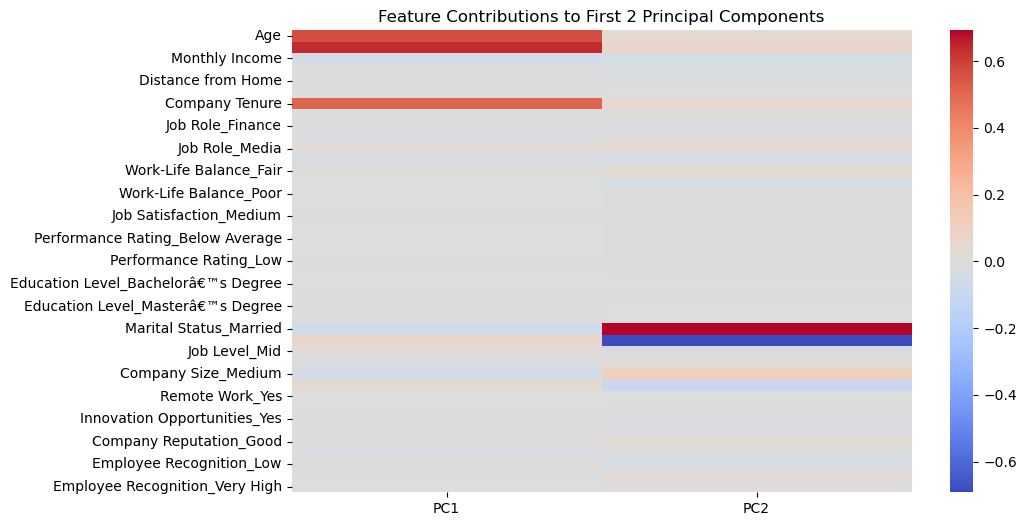

In [7]:
# PCA component loadings
loadings = pd.DataFrame(pca_2d.components_.T,
                        columns=["PC1", "PC2"],
                        index=X_all.columns)

plt.figure(figsize=(10,6))
sns.heatmap(loadings, cmap="coolwarm", center=0)
plt.title("Feature Contributions to First 2 Principal Components")
plt.show()


In [8]:
output_path = "D:\\ML\\Employee Attrition Prediction Dataset.csv"
df.to_csv(output_path, index=False)
